# 03 - Tuning XGBoost con CV por hogar

Usa 5-CV estratificado por `household_id`, mide GMPCA, y busca con hyperopt. Guarda los mejores hiperparámetros en `artifacts/lpmc_xgb_custom_params.json`.


## 1. Introducción

En esta libreta replico el tuning de XGBoost sobre LPMC de forma parecida a la que hizo Jose Angel. Cargo el train preprocesado, defino el espacio de búsqueda de hiperparámetros, uso 5-CV estratificado por household_id y mido GMPCA. Al final guardo mis mejores hiperparámetros en lpmc_xgb_custom_params.json para usarlos en la libreta 04.

## 2. Carga de datos y rutas

Leo LPMC_train.csv desde data/preprocessed, separo features y la columna objetivo travel_mode, y preparo la carpeta de artefactos. Muestro la forma del train para saber con cuántas filas y columnas trabajo

In [33]:
from pathlib import Path
import json
import numpy as np
import pandas as pd

ROOT = Path.cwd()
DATA_DIR = ROOT / 'data' / 'preprocessed'
ARTIFACTS = ROOT / 'artifacts'
ARTIFACTS.mkdir(exist_ok=True)
train = pd.read_csv(DATA_DIR / 'LPMC_train.csv')

target_col = 'travel_mode'
X_full = train.drop(columns=[target_col])
y_full = train[target_col].astype(int)
print('Dimensiones train completas:', X_full.shape)


Dimensiones train completas: (54766, 28)


## 3. Hiperparámetros de Jose Angel como referencia

Cargo el JSON lpmc_xgb_best_params.json (los hiperparámetros del tutor) y la lista de columnas que se escalan. Solo los muestro como referencia para comparar con lo que encuentre en mi búsqueda.

In [34]:
# Cargar hiperparámetros del profe para referencia
best_prof_path = ARTIFACTS / 'lpmc_xgb_best_params.json'
with best_prof_path.open() as f:
    best_prof_bundle = json.load(f)
best_prof_params = best_prof_bundle['params']
scaled_features = best_prof_bundle['scaled_features']
print('Hiperparámetros del profe:')
for k, v in best_prof_params.items():
    print(f"  {k}: {v}")


Hiperparámetros del profe:
  max_depth: 4
  gamma: 3.931781434966718
  min_child_weight: 35
  max_delta_step: 9
  subsample: 0.7667332690572212
  colsample_bytree: 0.9343084611837867
  colsample_bylevel: 0.6514580147153639
  reg_alpha: 0.04829946881115557
  reg_lambda: 0.037112340554694714
  n_estimators: 4809
  learning_rate: 0.01
  objective: multi:softprob
  eval_metric: mlogloss
  num_class: 4
  n_jobs: -1
  random_state: 42


## 4. Funciones auxiliares y seed

Defino RANDOM_STATE = 481516 para reproducibilidad. Incluyo la función de CV estratificada por household_id (la misma idea que en el repo de Jose Angel para que no caiga en el mismo conjunto personas de la misma casa porque tienen mucha correlación) y la función gmpca_from_proba, que calcula GMPCA a partir de las probabilidades. Todo esto se usa dentro del objetivo de hyperopt.

In [35]:
# Funciones auxiliares
from collections import Counter, defaultdict

RANDOM_STATE = 481516

# Stratified Group K-Fold (copiado del repo del profe)
def stratified_group_k_fold(X, y, groups, k, seed=None):
    labels_num = int(np.max(y)) + 1
    y_counts_per_group = defaultdict(lambda: np.zeros(labels_num))
    y_distr = Counter()
    for label, g in zip(y, groups):
        y_counts_per_group[g][label] += 1
        y_distr[label] += 1

    y_counts_per_fold = defaultdict(lambda: np.zeros(labels_num))
    groups_per_fold = defaultdict(set)

    def eval_y_counts_per_fold(y_counts, fold):
        y_counts_per_fold[fold] += y_counts
        std_per_label = []
        for label in range(labels_num):
            label_std = np.std([y_counts_per_fold[i][label] / y_distr[label] for i in range(k)])
            std_per_label.append(label_std)
        y_counts_per_fold[fold] -= y_counts
        return np.mean(std_per_label)

    groups_and_y_counts = list(y_counts_per_group.items())
    rng = np.random.default_rng(seed)
    rng.shuffle(groups_and_y_counts)

    for g, y_counts in sorted(groups_and_y_counts, key=lambda x: -np.std(x[1])):
        best_fold = None
        min_eval = None
        for i in range(k):
            fold_eval = eval_y_counts_per_fold(y_counts, i)
            if min_eval is None or fold_eval < min_eval:
                min_eval = fold_eval
                best_fold = i
        y_counts_per_fold[best_fold] += y_counts
        groups_per_fold[best_fold].add(g)

    all_groups = set(groups)
    for i in range(k):
        train_groups = all_groups - groups_per_fold[i]
        test_groups = groups_per_fold[i]
        train_indices = [idx for idx, g in enumerate(groups) if g in train_groups]
        test_indices = [idx for idx, g in enumerate(groups) if g in test_groups]
        yield train_indices, test_indices


def gmpca_from_proba(proba, y_true):
    proba = np.asarray(proba)
    y_true = np.asarray(y_true)
    proba = np.clip(proba, 1e-12, 1.0)
    log_like = np.log(proba[np.arange(len(y_true)), y_true]).sum()
    return float(np.exp(log_like / len(y_true)))


## 5. Configuración del tuning

Activo o no el tuning con RUN_TUNING. Fijo MAX_EVALS (número de evaluaciones de hyperopt), CV (número de folds) y SAMPLE_FRAC (fracción del train que uso para abaratar costes, igual que hacía Jose Angel). Con hyperopt (hp y tpe) defino el espacio de búsqueda: profundidad, gamma, min_child_weight, subsample, colsample_bytree, reg_alpha, reg_lambda, n_estimators y learning_rate.

In [36]:
RUN_TUNING = True  # False para no lanzar la búsqueda
MAX_EVALS = 80    # subir para más precisión
CV = 5
SAMPLE_FRAC = 0.25  # igual que el original

In [37]:
try:
    import hyperopt
    from hyperopt import hp, tpe, fmin, Trials
    from sklearn.preprocessing import StandardScaler
    from xgboost import XGBClassifier
    HAVE_HYPEROPT = True
except ImportError:
    HAVE_HYPEROPT = False
    print('hyperopt no está instalado; usa `pip install --user hyperopt`')


## 6. Ejecutamos Tuning

En objective convierto los valores de hyperopt a tipos correctos, añado los parámetros fijos (multi:softprob, eval_metric mlogloss, num_class=4, n_jobs=-1, random_state fijo) y recorro los folds precomputados. En cada fold escalo las columnas numéricas, entreno un XGBoost y obtengo las probabilidades para calcular la log-verosimilitud negativa (que hyperopt minimiza). Tras max_evals, muestro el mejor conjunto (best_search).

Transformo best_search a un diccionario limpio con enteros/float y añado los parámetros fijos. Guardo todo en lpmc_xgb_custom_params.json junto con la configuración de CV, número de evaluaciones, fracción muestreada y la lista de columnas escaladas. Ese JSON es el que usaré en la libreta 04 si pongo PARAM_SOURCE = 'custom'.

In [38]:
if RUN_TUNING and HAVE_HYPEROPT:
    # Sample como en el script original
    rng = np.random.default_rng(RANDOM_STATE)
    sample_idx = rng.choice(len(X_full), size=int(len(X_full) * SAMPLE_FRAC), replace=False)
    X_sample = X_full.iloc[sample_idx].reset_index(drop=True)
    y_sample = y_full.iloc[sample_idx].reset_index(drop=True)

    groups = np.array(X_sample['household_id'].values)
    X_sample = X_sample.drop(columns=['household_id'])

    # Build folds
    train_indices = []
    test_indices = []
    for tr_idx, te_idx in stratified_group_k_fold(X_sample, y_sample, groups, k=CV, seed=RANDOM_STATE):
        train_indices.append(tr_idx)
        test_indices.append(te_idx)

    space = {
        'max_depth': hp.quniform('max_depth', 3, 12, 1),
        'gamma': hp.loguniform('gamma', -5, 1),
        'min_child_weight': hp.quniform('min_child_weight', 1, 60, 1),
        'subsample': hp.uniform('subsample', 0.5, 0.9),
        'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
        'reg_alpha': hp.loguniform('reg_alpha', -7, 1),
        'reg_lambda': hp.loguniform('reg_lambda', -7, 1),
        'n_estimators': hp.quniform('n_estimators', 300, 2000, 50),
        'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
    }

    def objective(space):
        params = {k: int(v) if k in ['max_depth', 'min_child_weight', 'n_estimators'] else float(v)
                  for k, v in space.items()}
        params.update({
            'objective': 'multi:softprob',
            'eval_metric': 'mlogloss',
            'num_class': 4,
            'n_jobs': -1,
            'random_state': RANDOM_STATE,
        })

        loss = 0.0
        n_total = 0
        for tr_idx, te_idx in zip(train_indices, test_indices):
            X_tr = X_sample.loc[tr_idx].copy()
            X_te = X_sample.loc[te_idx].copy()
            y_tr = y_sample.loc[tr_idx]
            y_te = y_sample.loc[te_idx]

            scaler = StandardScaler()
            X_tr[scaled_features] = scaler.fit_transform(X_tr[scaled_features].astype(float))
            X_te[scaled_features] = scaler.transform(X_te[scaled_features].astype(float))

            clf = XGBClassifier(**params)
            clf.fit(X_tr, y_tr)
            proba = clf.predict_proba(X_te)

            # cross-entropy (neg loglike) sum
            log_like = np.log(proba[np.arange(len(y_te)), y_te]).sum()
            loss -= log_like
            n_total += len(y_te)

        # average CE; hyperopt minimiza
        return {'loss': loss / n_total, 'status': hyperopt.STATUS_OK}

    trials = Trials()
    best_search = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=MAX_EVALS, trials=trials, rstate=np.random.default_rng(RANDOM_STATE))
    print('Mejor combo encontrado:', best_search)

    # Guardar como JSON de hiperparámetros custom
    best_custom = {k: int(v) if k in ['max_depth', 'min_child_weight', 'n_estimators'] else float(v)
                   for k, v in best_search.items()}
    best_custom.update({
        'objective': 'multi:softprob',
        'eval_metric': 'mlogloss',
        'num_class': 4,
        'n_jobs': -1,
        'random_state': RANDOM_STATE,
    })
    out_path = ARTIFACTS / 'lpmc_xgb_custom_params.json'
    payload = {
        'source': '03_tune_xgb.ipynb',
        'cv': CV,
        'max_evals': MAX_EVALS,
        'sample_frac': SAMPLE_FRAC,
        'params': best_custom,
        'scaled_features': scaled_features,
    }
    out_path.write_text(json.dumps(payload, indent=2))
    print('Hiperparámetros propios guardados en:', out_path)
else:
    print('RUN_TUNING=False o falta hyperopt; no se ha buscado nada.')


100%|██████████| 80/80 [14:55<00:00, 11.19s/trial, best loss: 0.6420760154724121]
Mejor combo encontrado: {'colsample_bytree': np.float64(0.9911780478619544), 'gamma': np.float64(2.499996019648383), 'learning_rate': np.float64(0.09258949217113338), 'max_depth': np.float64(6.0), 'min_child_weight': np.float64(17.0), 'n_estimators': np.float64(900.0), 'reg_alpha': np.float64(0.6836695859198154), 'reg_lambda': np.float64(0.053597416554023405), 'subsample': np.float64(0.6206611465973016)}
Hiperparámetros propios guardados en: f:\TFM\lpmc\artifacts\lpmc_xgb_custom_params.json


=== Resumen del tuning ===
CV: 5, MAX_EVALS: 80, SAMPLE_FRAC: 0.25, RANDOM_STATE: 481516
Mejor loss (media CE): 0.6421  -> GMPCA: 0.5262


,best_value
colsample_bytree,0.991178
gamma,2.499996
learning_rate,0.092589
max_depth,6.000000
min_child_weight,17.000000
n_estimators,900.000000
reg_alpha,0.683670
reg_lambda,0.053597
subsample,0.620661


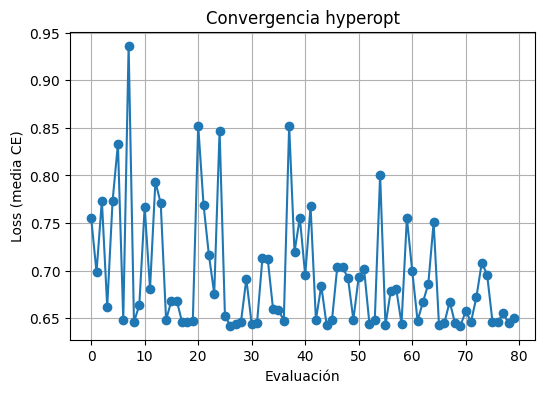

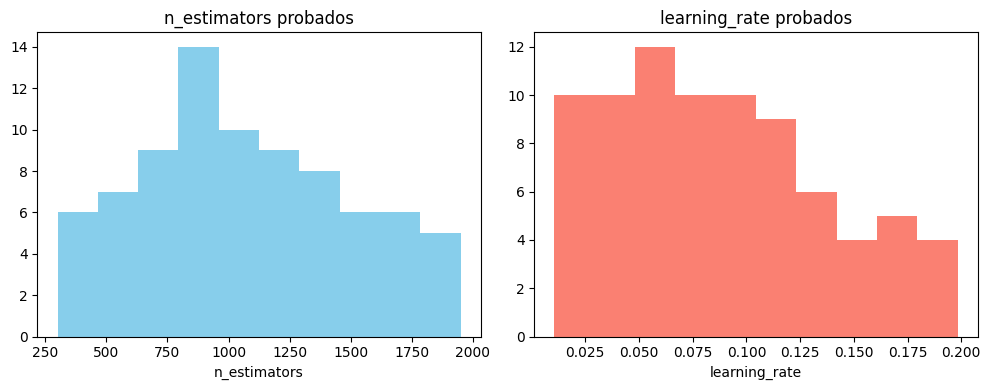

In [39]:
import matplotlib.pyplot as plt

# Resumen de la búsqueda
best_clean = {k: int(v) if k in ['max_depth','min_child_weight','n_estimators'] else float(v)
              for k, v in best_search.items()}
best_loss = trials.best_trial['result']['loss']
best_gmpca = float(np.exp(-best_loss))

print("=== Resumen del tuning ===")
print(f"CV: {CV}, MAX_EVALS: {MAX_EVALS}, SAMPLE_FRAC: {SAMPLE_FRAC}, RANDOM_STATE: {RANDOM_STATE}")
print(f"Mejor loss (media CE): {best_loss:.4f}  -> GMPCA: {best_gmpca:.4f}")
display(pd.DataFrame([best_clean]).T.rename(columns={0: "best_value"}))

# Curva de convergencia (loss por evaluación)
losses = [t['result']['loss'] for t in trials.trials]
plt.figure(figsize=(6,4))
plt.plot(losses, marker='o')
plt.xlabel("Evaluación")
plt.ylabel("Loss (media CE)")
plt.title("Convergencia hyperopt")
plt.grid(True)
plt.show()

# Distribuciones simples de n_estimators y learning_rate probados
if losses:
    ne_vals = [t['misc']['vals']['n_estimators'][0] for t in trials.trials]
    lr_vals = [t['misc']['vals']['learning_rate'][0] for t in trials.trials]
    fig, axes = plt.subplots(1, 2, figsize=(10,4))
    axes[0].hist(ne_vals, bins=10, color="skyblue")
    axes[0].set_title("n_estimators probados")
    axes[0].set_xlabel("n_estimators")
    axes[1].hist(lr_vals, bins=10, color="salmon")
    axes[1].set_title("learning_rate probados")
    axes[1].set_xlabel("learning_rate")
    plt.tight_layout()
    plt.show()
